# 1. Fetch data

Source: https://raw.githubusercontent.com/antimatter15/cameraman/master/cameraman.tif

In [ ]:
import urllib.request
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import tifffile

data = Path("data")
data.mkdir(exist_ok=True)
reference = Path("reference")

(256, 256) uint8 mean 118.7245 -> first.npy [0.0275, 0.9922]


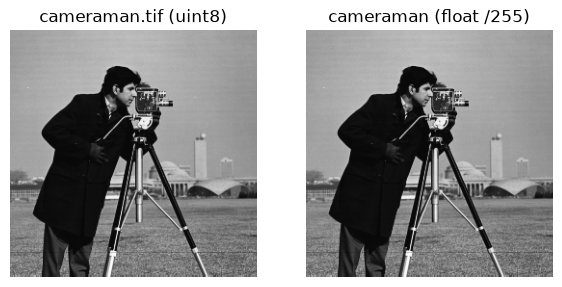

In [ ]:
URL = "https://raw.githubusercontent.com/antimatter15/cameraman/master/cameraman.tif"
raw_path = data / "cameraman.tif"

if not raw_path.exists():
    urllib.request.urlretrieve(URL, raw_path)

raw = tifffile.imread(raw_path)
cameraman = raw.astype(float) / 255.0

np.save(data / "first.npy", cameraman)
print(f"{raw.shape} {raw.dtype} mean {raw.mean():.4f} -> first.npy [{cameraman.min():.4f}, {cameraman.max():.4f}]")

fig, ax = plt.subplots(1, 2, figsize=(7, 3.6))
ax[0].imshow(raw, cmap="gray", vmin=0, vmax=255); ax[0].set_title("cameraman.tif (uint8)")
ax[1].imshow(cameraman, cmap="gray", vmin=0, vmax=1); ax[1].set_title("cameraman (float /255)")
for a in ax: a.axis("off")
plt.show()

The paper's second test image is not a file: Hansen's `blur.m` builds it from two ellipses, a triangle and a cross. `reference/blur.m` is that file (source and sha256 in `reference/README.md`).

(256, 256) levels [0.0, 0.25, 0.5, 0.75, 1.0] -> second.npy


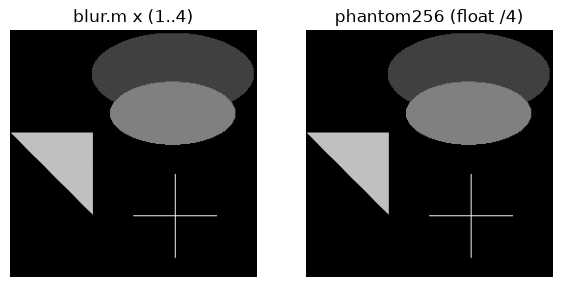

In [ ]:
def blur_image(N):
    """The image `blur.m` builds, at resolution N, in its intensities 1..4."""
    mround = lambda v: int(np.floor(v + 0.5))
    N2, N3, N6, N12 = (mround(N / k) for k in (2, 3, 6, 12))
    x = np.zeros((N, N))

    i = np.arange(1, N6 + 1)[:, None]
    j = np.arange(1, N3 + 1)[None, :]

    def ellipse(threshold):
        q = (((i / N6) ** 2 + (j / N3) ** 2) < threshold).astype(float)
        return np.concatenate([np.flipud(np.concatenate([np.fliplr(q), q], axis=1)),
                               np.concatenate([np.fliplr(q), q], axis=1)], axis=0)

    # MATLAB is 1-based, so `a + (1:m)` is the slice `[a : a+m]`
    x[2 : 2 + 2 * N6, N3 - 1 : N3 - 1 + 2 * N3] = ellipse(1.0)
    x[N6 : N6 + 2 * N6, N3 - 1 : N3 - 1 + 2 * N3] += 2.0 * ellipse(0.6)
    x[x == 3.0] = 2.0  # the two ellipses are summed, so their overlap needs correcting

    T = np.triu(np.ones((N3, N3)))
    x[N3 + N12 : N3 + N12 + T.shape[1], 1 : 1 + T.shape[0]] = 3.0 * T

    T = np.zeros((2 * N6 + 1, 2 * N6 + 1))
    T[N6, :] = 1.0
    T[:, N6] = 1.0
    x[N2 + N12 : N2 + N12 + T.shape[0], N2 : N2 + T.shape[1]] = 4.0 * T
    return x


raw_phantom = blur_image(256)
phantom = raw_phantom / 4.0

np.save(data / "second.npy", phantom)
print(f"{phantom.shape} levels {np.unique(phantom).tolist()} -> second.npy")

fig, ax = plt.subplots(1, 2, figsize=(7, 3.6))
ax[0].imshow(raw_phantom, cmap="gray", vmin=0, vmax=4); ax[0].set_title("blur.m x (1..4)")
ax[1].imshow(phantom, cmap="gray", vmin=0, vmax=1); ax[1].set_title("phantom256 (float /4)")
for a in ax: a.axis("off")
plt.show()